In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import getdist
from getdist import loadMCSamples, plots
import warnings
from copy import deepcopy

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300

columnwidth=246/72.27
textwidth=510/72.27

matplotlib.rcParams['axes.titlesize'] = 10
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['legend.fontsize'] = 10
matplotlib.rcParams['legend.title_fontsize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10

from scipy.interpolate import interp1d
from scipy.integrate import quad

In [6]:

choice = 0
filepaths = [
    './data/roman_real/roman_lcdm_baseline_mcmc/',
    './data/roman_fourier/roman_lcdm_baseline_mcmc/',
    './data/lsst_real/lsst_lcdm_baseline_mcmc/',
    './data/lsst_fourier/lsst_lcdm_baseline_mcmc/',
    ]
labels = [r'Roman real',
          r'Roman fourier',
          r'Rubin real',
          r'Rubin fourier',]
cmap = plt.get_cmap("viridis")
colors = [tuple(cmap(x)) for x in np.linspace(0, 1, len(labels))]
def load(filepath, settings):
    samples = loadMCSamples(filepath, settings=settings)
    #samples.thin(50)
    
    #indxs = samples.random_single_samples_indices(max_samples=20000, random_state=0)
    #loglikes = None if samples.loglikes is None else samples.loglikes[indxs]
    #samples.setSamples(samples.samples[indxs], weights=None, loglikes=loglikes)
    
    p = samples.getParams()
    s8 = p.sigma8*(p.omegam/0.3)**0.5
    try:
        samples.addDerived(
            s8,
            'S8',
            label = r'S_8',
        )
    except:
        True
    return samples
settings = {'ignore_rows':0.2, 'contours': [0.68, 0.95]}
samples = []
for i in range(len(labels)):
    samples.append(load(filepaths[i], settings = settings))
    # clear wrong latex
    pn = samples[-1].getParamNames()
    latex_As = r'10^{9} A_{\rm s}'
    for p in pn.names:
        if p.name == 'mnu':
            p.label = r'm_{\nu}'
        if p.name.lower() == 'omegan':
            p.label = r'\Omega_{\nu}'
        if p.name == 'As_1e9':
            p.label = latex_As
fiducials ={
    'As_1e9': 2.1,
    'ns': 0.96605,
    'H0': 67.32,
    'omegab': 0.0495,
    'omegam': 0.316,
    'sigma8': 0.81164266,
    'mnu': 0.06,
    'w': -1.0,
    'roman_DZ_S1': 0.0,
    'roman_DZ_S2': 0.0,
    'roman_DZ_S3': 0.0,
    'roman_DZ_S4': 0.0,
    'roman_DZ_S5': 0.0,
    'roman_DZ_S6': 0.0,
    'roman_DZ_S7': 0.0,
    'roman_DZ_S8': 0.0,
    
    'roman_DZ_L1': 0.0,
    'roman_DZ_L2': 0.0,
    'roman_DZ_L3': 0.0,
    'roman_DZ_L4': 0.0,
    'roman_DZ_L5': 0.0,
    'roman_DZ_L6': 0.0,
    'roman_DZ_L7': 0.0,
    'roman_DZ_L8': 0.0,
    'roman_DZ_L9': 0.0,
    'roman_DZ_L10': 0.0,
    
    'roman_M1': 0.0,
    'roman_M2': 0.0,
    'roman_M3': 0.0,
    'roman_M4': 0.0,
    'roman_M5': 0.0,
    'roman_M6': 0.0,
    'roman_M7': 0.0,
    'roman_M8': 0.0,
    
    'roman_A1_1': 0.5,
    'roman_A1_2': 0.0,
    'roman_A2_1': 0.0,
    'roman_A2_2': 0.0,
    'roman_BTA_1': 0.0,
    
    'roman_B1_1': 1.09,
    'roman_B1_2': 1.15,
    'roman_B1_3': 1.21,
    'roman_B1_4': 1.27,
    'roman_B1_5': 1.33,
    'roman_B1_6': 1.40,
    'roman_B1_7': 1.46,
    'roman_B1_8': 1.53,
    'roman_B1_9': 1.60,
    'roman_B1_10': 1.67,
}


fiducials['S8'] = fiducials['sigma8']*(fiducials['omegam']/0.3)**0.5


<Figure size 340.39x340.39 with 0 Axes>

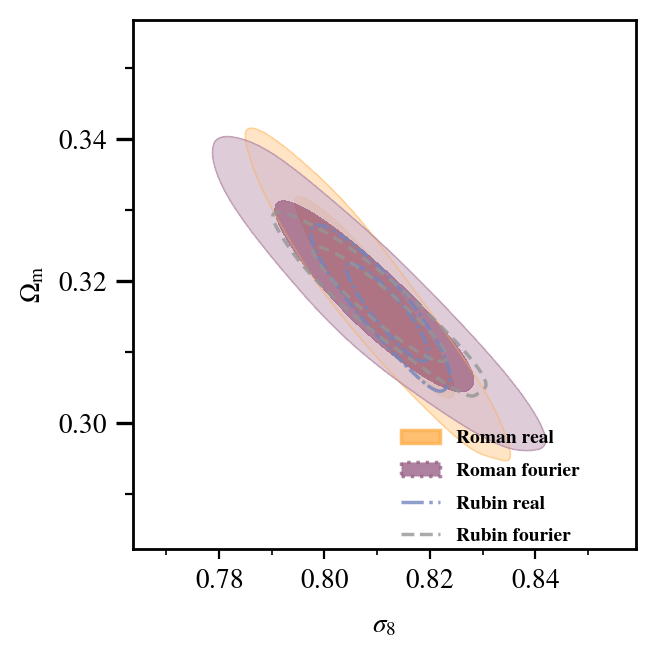

In [7]:
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from getdist import plots

g = plots.get_single_plotter(width_inch=columnwidth, ratio=1)
g.settings.title_limit = 1
g.settings.title_limit_labels = True
g.settings.title_limit_fontsize = 10
g.settings.lab_fontsize = 10
g.settings.legend_fontsize = 10
g.settings.figure_legend_frame = False
g.settings.axes_fontsize = 10
g.settings.axes_labelsize = 10
g.settings.axis_tick_max_labels = 4

params = ['sigma8', 'omegam']

g.plots_2d(
    samples, 
    param_pairs=[params], 
    legend_labels= labels,
    colors=['#FFAF4C', '#9A6289', '#7386BE', '#959596'],
    ls = ['-',':','-.','--'],
    lws = [1.25, 1.25, 1.25, 1.25],
    alphas = [0.8, 0.8, 0.8, 0.8],
    filled = [True, True, False, False],
)

ax = g.get_axes()
colors=['#FFAF4C', '#9A6289', '#7386BE', '#959596', '#4C9987']
means = [sample.getMeans() for sample in samples]
for i in range(len(samples)):
    p = samples[i].getParamNames()
    ix = p.numberOfName('omegam')
    iy = p.numberOfName('S8')
    ax.plot(means[i][ix], means[i][iy], marker='x', color=colors[i], markersize=3)#, markeredgecolor='k', markeredgewidth=0.2
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
ax.yaxis.set_major_locator(MultipleLocator(0.02))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))
ax.xaxis.set_major_locator(MultipleLocator(0.02))
ax.xaxis.set_minor_locator(MultipleLocator(0.01))

colors = ['#FFAF4C', '#9A6289', '#7386BE', '#959596', '#4C9987']
linestyles = ['-', ':', '-.', '--']
alphas = [0.8, 0.8, 0.8, 0.8, 0.8]
filled_flags = [True, True, False, False, True]

dataset_handles = []
for lab, c, ls, a, is_filled in zip(labels, colors, linestyles, alphas, filled_flags):
    if is_filled:
        h = Patch(facecolor=c, edgecolor=c, linestyle=ls, linewidth=1.25, alpha=a, label=lab)
    else:
        h = Line2D([0], [0], color=c, linestyle=ls, linewidth=1.25, alpha=a, label=lab)
    dataset_handles.append(h)

if g.legend is not None:
    g.legend.remove()

g.legend = g.fig.legend(
    handles=dataset_handles,
    loc=(0.6,0.16),
    frameon=False,
    ncol=1,
    prop={'weight':'bold', 'size':7},
)
g.extra_artists = [g.legend]
'''
#fix the line
dash_map = {
    '#959596': (0, (3, 1, 1, 1, 1, 1)),
    '#4C9987': (0, (5, 1, 2, 1, 3, 1)),
}
targets = {matplotlib.colors.to_rgb(k): v for k, v in dash_map.items()}
def rgb_close(a, b, tol=3e-3):
    return all(abs(a[i]-b[i]) < tol for i in range(3))

def get_rgb_from_artist(a):
    # contour 线通常在 edgecolor；填充在 facecolor
    for getter in ("get_edgecolor", "get_facecolor"):
        if hasattr(a, getter):
            c = getattr(a, getter)()
            if c is not None and len(np.atleast_2d(c)):
                return tuple(np.atleast_2d(c)[0][:3])
    return None

def set_dash_line2d(ln, dash):
    if isinstance(dash, tuple) and len(dash) == 2:
        ln.set_linestyle(dash)
    else:
        ln.set_dashes(list(dash))

from matplotlib.contour import QuadContourSet
changed = 0
for ax in g.fig.axes:
    for obj in ax.collections:
        if isinstance(obj, QuadContourSet):
            # 真正的线/面在 obj.collections 里
            for sub in obj.collections:
                rgb = get_rgb_from_artist(sub)
                if rgb is None:
                    continue
                for trgb, dash in targets.items():
                    if rgb_close(rgb, trgb):
                        # 关键：对 Collection 用 [dash]，避免被当成可迭代 linestyles 拆开
                        sub.set_linestyle([dash])
                        changed += 1
print("changed 2D contour collections:", changed)

n_changed = 0
for ax in g.fig.axes:
    for ln in ax.lines:
        rgb = matplotlib.colors.to_rgb(ln.get_color())
        for target_rgb, dash in targets.items():
            if rgb_close(rgb, target_rgb):
                set_dash_line2d(ln, dash)
                n_changed += 1
print("changed 2D margin lines:", changed)
plt.show()
'''
g.export(f'approximation_contour_all_lcdm.pdf')


In [44]:
from collections import Counter

for i, ax in enumerate(g.fig.axes):
    types_col = Counter(type(c).__name__ for c in ax.collections)
    types_lin = Counter(type(l).__name__ for l in ax.lines)
    print(f"\nAX {i}:")
    print("  collections:", dict(types_col))
    print("  lines      :", dict(types_lin))


AX 0:
  collections: {'QuadContourSet': 7, 'PathCollection': 12}
  lines      : {'Line2D': 2}


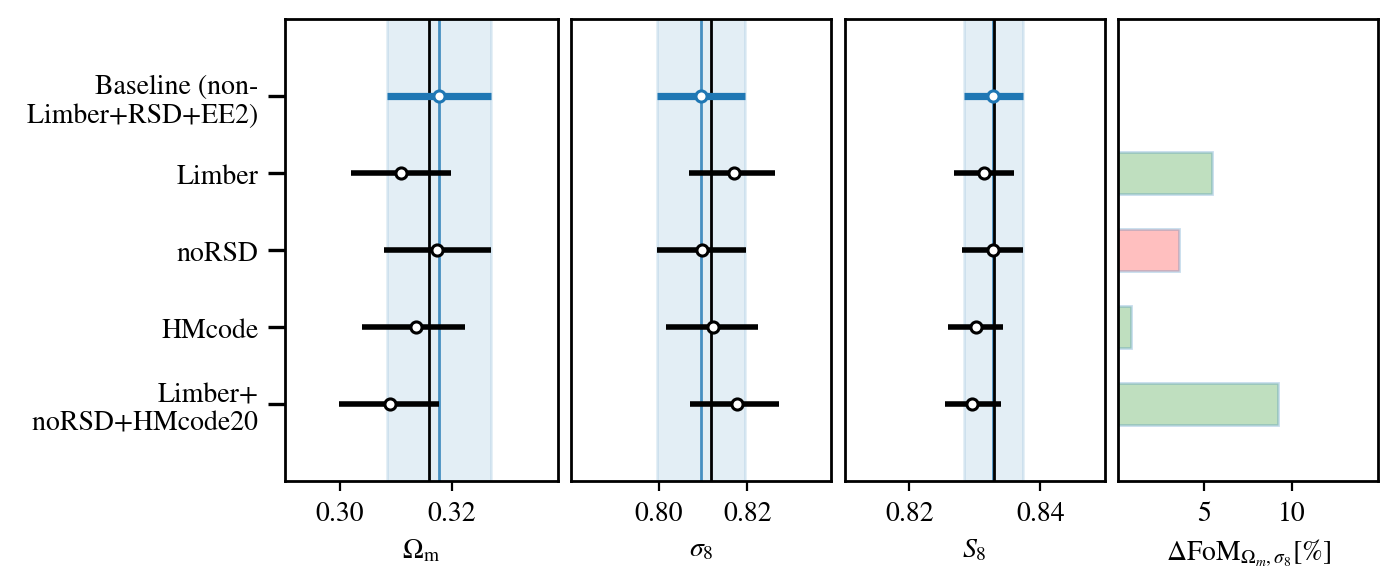

In [45]:
res0 = 0

def plot_row(axs, labels, samples, params, color='C0', ):
    
    assert len(axs)==len(params)+1
    
    assert len(labels)==len(samples)
    
    nparam = len(params)
    ys = np.arange(len(samples))[::-1]
    
    # set the space of baseline, assume the first chain is the baseline
    for i in range(nparam):
        p = params[i]
        stat = samples[0].getMargeStats().parWithName(p)
        mean = stat.mean
        upper_bound = stat.limits[0].upper
        lower_bound = stat.limits[0].lower
        
        axs[i].axvspan(lower_bound, upper_bound, color=color, alpha=0.12, zorder=0)
        axs[i].axvline(mean, color=color, lw=1, alpha=0.8, zorder=0)
        axs[i].axvline(fiducials[p], color='k',lw=1,alpha=1,zorder=0)
        axs[i].set_xlim(mean-3*(mean-lower_bound), mean+3*(upper_bound-mean))
        axs[i].set_ylim(ys[-1]-1, ys[0]+1)
    
    # set the labels of chains
    axs[0].set_yticks(ys)
    axs[0].set_yticklabels(labels)
    
    for i in range(1,len(axs)):
        axs[i].set_yticks(ys)
        axs[i].tick_params(axis='y', left=False)
        axs[i].set_yticklabels([])
        axs[i].set_ylim(ys[-1]-1, ys[0]+1)
        
    # plot the error bar
    for i in range(len(samples)):
        sample = samples[i]
        y = ys[i]
        c = color if i==0 else 'k'
        lw = 2.6 if i==0 else 2.0
        for j in range(len(params)):
            ax = axs[j]
            p = params[j]
            stat = sample.getMargeStats().parWithName(p)
            mean = stat.mean
            upper_bound = stat.limits[0].upper
            lower_bound = stat.limits[0].lower
            
            ax.hlines(y, lower_bound, upper_bound, color=c, lw=lw)
            ax.plot(mean,y,marker='o',mfc='white',mec=c,mew=1.1,ms=4,linestyle='None')
            
            #set x-axis
            if i==0:
                ax.set_xlabel(sample.getParamNames().parWithName(p).latexLabel())

        #now get the estimation of FoM
        p1 = params[0]
        p2 = params[1]
        names = [n.name for n in sample.getParamNames().names]
        a, b = names.index(p1), names.index(p2)
        cov = sample.getCov(pars=[a,b])
        det = np.linalg.det(cov)
        res = np.nan if det <= 0 or not np.isfinite(det) else 1.0 / np.sqrt(det)

        if i==0:
            res0 = res
        else:
            if res-res0>0:
                axs[-1].barh(y, (res-res0)/res0*100, height=0.55, alpha=0.25, color='green', edgecolor=color)
            elif res-res0<0:
                axs[-1].barh(y, np.abs(res-res0)/res0*100, height=0.55, alpha=0.25, color='red', edgecolor=color)
        
        #set x-axis for FoM
        if i==0:
            axs[-1].set_xlabel(r'$ \Delta \mathrm{FoM}_{\Omega_m, \sigma_8} [\%]$')
        
    
fig = plt.figure(figsize = (textwidth, 3))
gs = fig.add_gridspec(1,4,width_ratios=[1.05, 1.0, 1.0, 1.0],wspace=0.05, hspace=0.2)
axs = [fig.add_subplot(gs[i]) for i in range(4)]

plot_row(axs=axs, labels=labels, samples=samples, color='C0', params=['omegam','sigma8','S8'], )

#finetue the plot settings
axs[-1].set_xlim(0.1, 15-0.1)
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
axs[0].set_xlim(0.2901, 0.34-0.001)
axs[0].xaxis.set_major_locator(MultipleLocator(0.02))
axs[1].set_xlim(0.7801, 0.84-0.001)
axs[1].xaxis.set_major_locator(MultipleLocator(0.02))
axs[2].set_xlim(0.8101, 0.85-0.0001)
axs[2].xaxis.set_major_locator(MultipleLocator(0.02))

fig.savefig('approximation_FoM_roman_lcdm_real.pdf', dpi=300 )